<a href="https://colab.research.google.com/github/procoder369/ML-Projects/blob/main/digit_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
'''             DIGITS DATASET
                    ↓
             X = Pixel values
             y = Digit labels
                    ↓
             Train/Test Split
                    ↓
              KNN Classifier
                    ↓
             knn.fit()
                    ↓
             knn.predict()
                    ↓
          Accuracy / Confusion Matrix  '''


'             DIGITS DATASET\n                    ↓\n             X = Pixel values\n             y = Digit labels\n                    ↓\n             Train/Test Split\n                    ↓\n              KNN Classifier\n                    ↓\n             knn.fit()\n                    ↓\n             knn.predict()\n                    ↓\n          Accuracy / Confusion Matrix  '

In [26]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt


In [27]:
digits=load_digits()
X=digits.data
y=digits.target
print(X.shape)
print(y.shape)

(1797, 64)
(1797,)


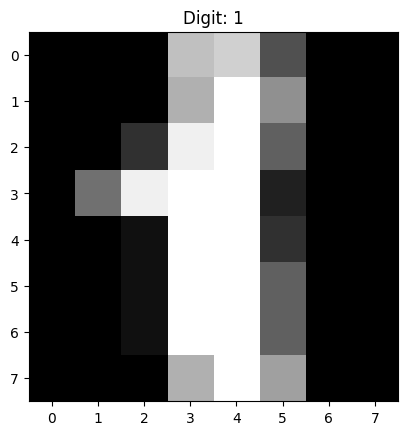

In [28]:
plt.imshow(digits.images[1], cmap="gray")
plt.title(f"Digit: {digits.target[1]}")
plt.show()

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
knn = KNeighborsClassifier(n_neighbors=5)


In [31]:
##train and test the model
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [32]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9861111111111112


In [33]:
## confussion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[33  0  0  0  0  0  0  0  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 33  0  0  0  0  0  0  0]
 [ 0  0  0 34  0  0  0  0  0  0]
 [ 0  0  0  0 46  0  0  0  0  0]
 [ 0  0  0  0  0 45  1  0  0  1]
 [ 0  0  0  0  0  0 35  0  0  0]
 [ 0  0  0  0  0  0  0 33  0  1]
 [ 0  0  0  0  0  0  0  0 30  0]
 [ 0  0  0  0  1  1  0  0  0 38]]


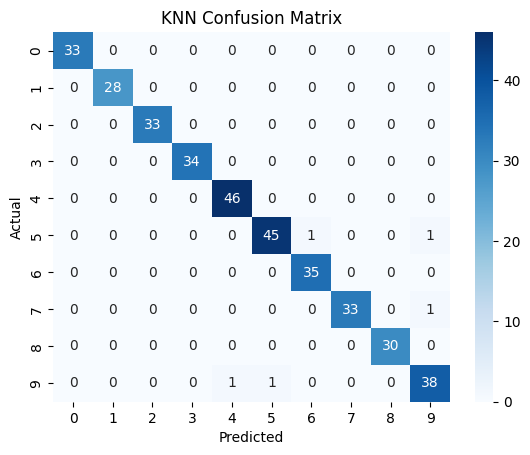

In [34]:
import seaborn as sns

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")

plt.show()

In [36]:
## test the model using my hand written numbers

from google.colab import files

uploaded = files.upload()

Saving sample_digits.png to sample_digits (1).png


In [37]:
print(uploaded.keys())

dict_keys(['sample_digits (1).png'])


In [38]:
from PIL import Image
import numpy as np

img = Image.open("sample_digits.png")

print(img.size)

(1200, 480)


In [39]:
img = img.convert("L")
img = img.resize((8, 8))

In [40]:
img_array = np.array(img)

print(img_array)
print(img_array.shape)

[[220 240 225 237 228 214 247 240]
 [168 201 168 206 183 170 234 211]
 [193 206 162 190 206 205 192 154]
 [191 226 186 200 195 191 221 197]
 [210 239 218 229 199 204 229 219]
 [145 194 197 215 184 164 185 150]
 [202 190 155 198 208 157 216 171]
 [193 214 174 221 243 172 226 205]]
(8, 8)


In [41]:
img_flatten = img_array.reshape(1, 64)

print(img_flatten.shape)

(1, 64)


In [46]:
# Test the first 10 images
predictions = knn.predict(digits.data[:10])

print("Predictions:", predictions)
print("Actual:     ", digits.target[:10])

Predictions: [0 1 2 3 4 9 6 7 8 9]
Actual:      [0 1 2 3 4 5 6 7 8 9]


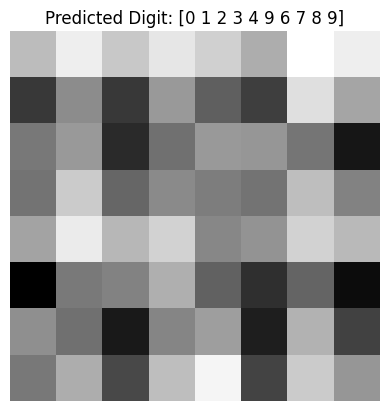

In [53]:
# Display image
plt.imshow(img_array, cmap="gray")
plt.title(f"Predicted Digit: {predictions[:10]}")
plt.axis("off")
plt.show()